# Gradiente Descendiente

## Regresión lineal con Gradiente Descendiente

Para entender este concepto, junto con el del optimización, recomiendo revisar el archivo "Optimizacion.ipynb" dentro de este mismo repositorio, ubicado en `/humai/04_Math_for_AI/Optimizacion`. Allí se explica en detalle el concepto del cual proviene el gradiente descendiente, su relación con las derivadas, cómo se calcula, etc.

Este notebook es solo un ejemplo más simple, en el cual intentaremos generar un modelo de regresión lineal "a mano" utilizando el gradiente descendiente y luego lo compararemos con la implementación propia de `scikit-learn`. 

A grandes rasgos, el gradiente descendiente no es otra cosa que un algoritmo iterativo que nos permite obtener los valores que nos brindan el mínimo de una función de costo.

En el caso de la regresión lineal, nuestra función de costo sería la función de error (ver distintas funciones de error en este repo en `/codigo_maquina/Nivel_5_Aprendizaje_de_maquina/Metricas_de_regresion.ipynb`). La función más utilizada es el error cuadrático medio o MSE, pero en este caso utilizaremos la suma de los cuadrados de los residuos RSS, que es igual al MSE pero sin dividir la sumatoria por la cantidad total de observaciones. Lo que nos interesa es obtener los valores de $b$ ($b0$ que sería la ordenada al origen, $b1$ que sería el coeficiente 1, etc) que harán que el cálculo del error sea el mínimo posible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [10]:
# Variable independiente
experiencia = np.array([[5], [6], [13]])

# Variable dependiente
salario = np.array([6.85, 16.83, 26.84])

modelo = LinearRegression().fit(experiencia, salario)

# Visualización de datos y modelo
print("Intersección con eje Y (b): %0.2f" % modelo.intercept_)
print("Pendiente (m): %0.2f" % modelo.coef_[0])
print("Suma de cuadrados de los residuos (RSS): %0.2f" %
      ((salario - modelo.predict(experiencia))**2).sum())
print("RSS usando scikit-learn:", round(mean_squared_error(salario, modelo.predict(experiencia)) * salario.shape[0], 2))

Intersección con eje Y (b): 0.00
Pendiente (m): 2.10
Suma de cuadrados de los residuos (RSS): 31.42
RSS usando scikit-learn: 31.42


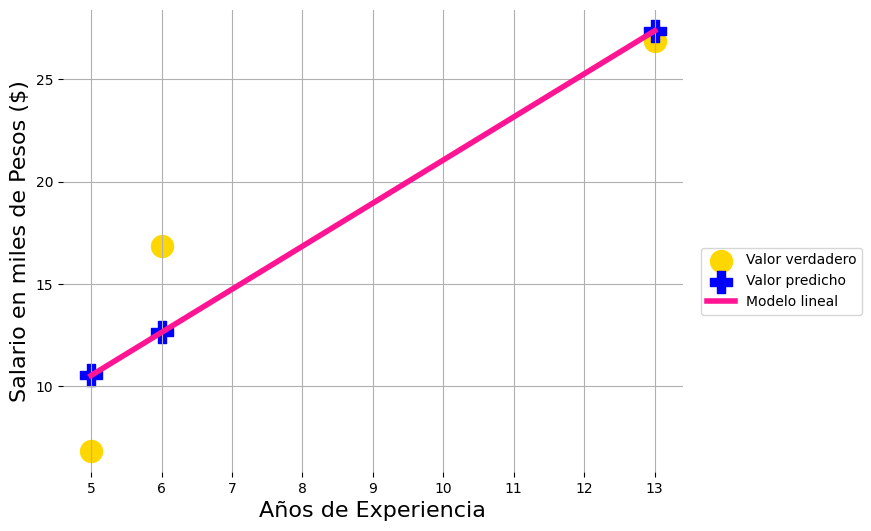

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(experiencia, salario, color="gold", s=250,
            marker="o", label="Valor verdadero")

plt.scatter(experiencia, modelo.predict(experiencia),
            color="blue", s=250, marker="P", label="Valor predicho") 

plt.plot(experiencia, modelo.predict(experiencia),
         linewidth=4, color="deeppink", label="Modelo lineal") 

experiencia = experiencia.reshape(3)

plt.ylabel("Salario en miles de Pesos ($)", size=16)
plt.xlabel("Años de Experiencia", size=16)
plt.legend(bbox_to_anchor=(1.3, 0.5))
plt.grid()
plt.box(False)
plt.show()

### Diferentes modelos con diferentes pendientes

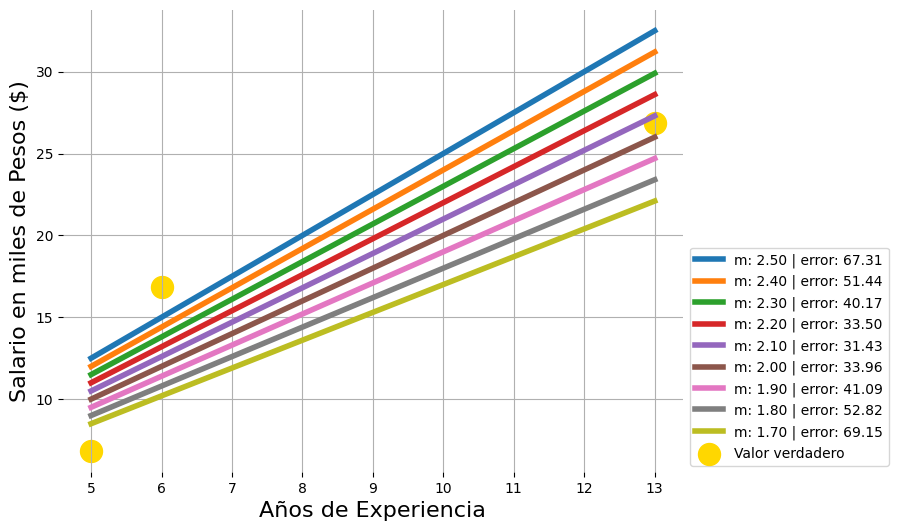

In [12]:
# Creación de múltiples pendientes para exploración
pendientes = np.arange(2.5, 1.6, -0.1)

# Vector para almacenar el error de los diferentes modelos
errores = np.array([])

# Visualización de modelos

plt.figure(figsize=(8, 6))

for pendiente in pendientes: 
    # Error del modelo (suma de cuadrados de los residuos)
    # recordar que para este ejemplo tenemos el b0 = 0 para simplicar el caso
    error = ((salario - pendiente*experiencia)**2).sum()

    # Visualización de un modelo para una pendiente dada
    plt.plot(experiencia, pendiente*experiencia, linewidth=4, 
             label="m: %0.2f | error: %0.2f" %
            (pendiente, error)) 
    
    errores = np.append(errores, error)

plt.scatter(experiencia, salario, color="gold", s=250,
            marker="o", label="Valor verdadero")

plt.ylabel("Salario en miles de Pesos ($)", size=16)
plt.xlabel("Años de Experiencia", size=16)
plt.legend(bbox_to_anchor=(1, 0.5))
plt.grid()
plt.box(False)
plt.show()

### Visualización de los errores

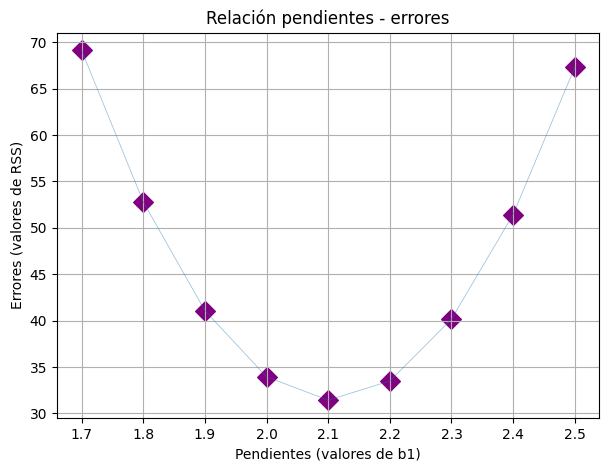

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(pendientes, errores, marker="D", color="purple", s=100)
plt.plot(pendientes, errores, linewidth=0.5, alpha=0.5)
plt.title("Relación pendientes - errores")
plt.xlabel("Pendientes (valores de b1)")
plt.ylabel("Errores (valores de RSS)")
plt.grid()
plt.show()

Claramente vemos que el error es menor con una pendiente en particular y mayor con otras. 

El algoritmo del gradiente descendiente irá buscando iterativamente el valor de la pendiente con el que tendremos el menor error posible.

### Función de error a ser minimizada

#### Suma de los cuadrados de los residuos (RSS)

$RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

donde:

- $n$ es el número total de observaciones.
- $y_i$ es el valor real (o verdadero) de la \(i\)-ésima observación (en este caso, el salario).
- $\hat{y}_i$ es el valor predicho por el modelo para la \(i\)-ésima observación (sería la pendiente * experiencia).
- $(y_i - \hat{y}_i)^2$ es el cuadrado de la diferencia entre el valor real y el valor predicho para la $i$-ésima observación.

In [19]:
# ingreso, experiencia
# persona 1 (6.85, 5) - persona 2 (16.83, 6) - persona 3 (26.84, 13)

m = sym.Symbol("m")

# Funcion de error
# error = (6.85 - m * 5)**2 + (16.83 - m * 6)**2 + (26.84 - m * 13)**2
error = ((salario - m * experiencia) ** 2).sum()

# Derivada de la funcion de error que nos sirve para encontrar el minimo de la funcion
deriv_error = sym.diff(error, m)

deriv_error

460.0*m - 968.3

In [20]:
for pendiente in pendientes:
    print(pendiente, "evaluada %0.2f" % deriv_error.evalf(subs={m : pendiente}))

2.5 evaluada 181.70
2.4 evaluada 135.70
2.3 evaluada 89.70
2.1999999999999997 evaluada 43.70
2.0999999999999996 evaluada -2.30
1.9999999999999996 evaluada -48.30
1.8999999999999995 evaluada -94.30
1.7999999999999994 evaluada -140.30
1.6999999999999993 evaluada -186.30


### Visualización - Derivada de la función del error

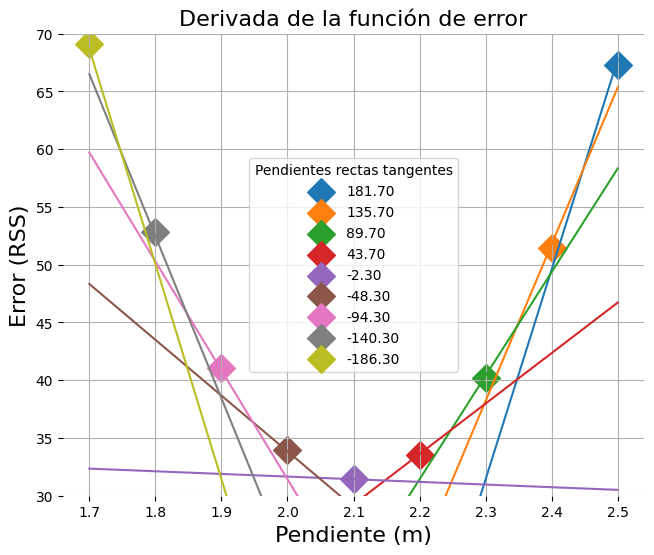

In [30]:
plt.figure(figsize=(7.5, 6))

for i in range(0, len(errores), 1):
    pendiente_recta_tangente_en_pendiente_error = deriv_error.evalf(subs={m : pendientes[i]})
    
    # Error de un modelo con cierta pendiente dada
    plt.scatter(pendientes[i], errores[i], 
                label="%0.2f" % pendiente_recta_tangente_en_pendiente_error, 
                marker="D", s=200)

    # Pendiente recta tangente en el punto formado por pendiente m y valor de error con esa m
    plt.plot(np.array([1.7, 2.5]), 
             np.array([1.7, 2.5])*pendiente_recta_tangente_en_pendiente_error + 
             pendiente_recta_tangente_en_pendiente_error * (-2.3 + i * 0.05) + errores.min())

plt.title("Derivada de la función de error", size=16)
plt.ylabel("Error (RSS)", size=16)
plt.xlabel("Pendiente (m)", size=16)
plt.legend(loc='center', title='Pendientes rectas tangentes')
plt.ylim(30, 70)
plt.grid()
plt.box(False)
plt.show()

### Generalizando para 2 o más parámetros: m y b

In [31]:
# Variable independiente
experiencia = np.array([[5], [8], [13]])

# Variable dependiente
salario = np.array([6.85, 16.83, 26.84])

modelo = LinearRegression().fit(experiencia, salario)

# Visualización de datos y modelo
print("Intersección con eje Y (b): %0.2f" % modelo.intercept_)
print("Pendiente (m): %0.2f" % modelo.coef_[0])
print("Suma de cuadrados de los residuos (RSS): %0.2f" %
      ((salario - modelo.predict(experiencia))**2).sum())
print("RSS usando scikit-learn:", round(mean_squared_error(salario, modelo.predict(experiencia)) * salario.shape[0], 2))

Intersección con eje Y (b): -4.38
Pendiente (m): 2.45
Suma de cuadrados de los residuos (RSS): 4.03
RSS usando scikit-learn: 4.03


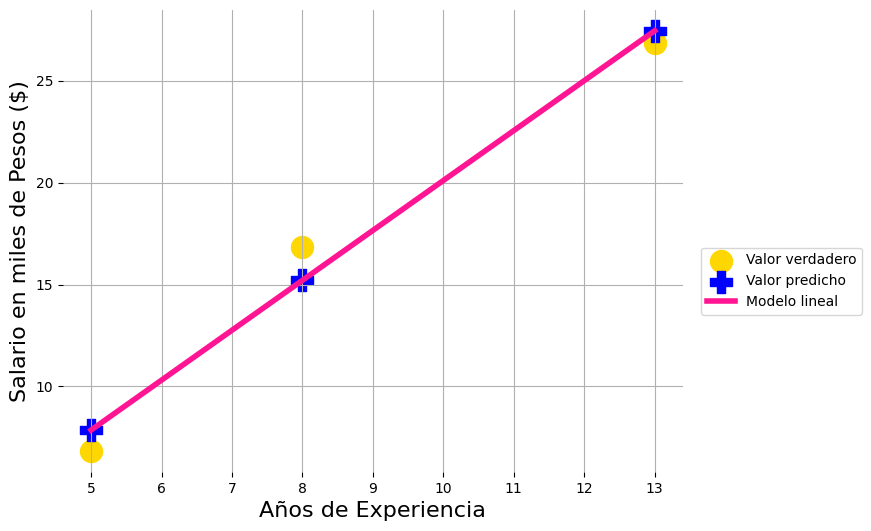

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(experiencia, salario, color="gold", s=250,
            marker="o", label="Valor verdadero")

plt.scatter(experiencia, modelo.predict(experiencia),
            color="blue", s=250, marker="P", label="Valor predicho") 

plt.plot(experiencia, modelo.predict(experiencia),
         linewidth=4, color="deeppink", label="Modelo lineal") 

plt.ylabel("Salario en miles de Pesos ($)", size=16)
plt.xlabel("Años de Experiencia", size=16)
plt.legend(bbox_to_anchor=(1.3, 0.5))
plt.grid()
plt.box(False)
plt.show()

### Función de Error (m, b)

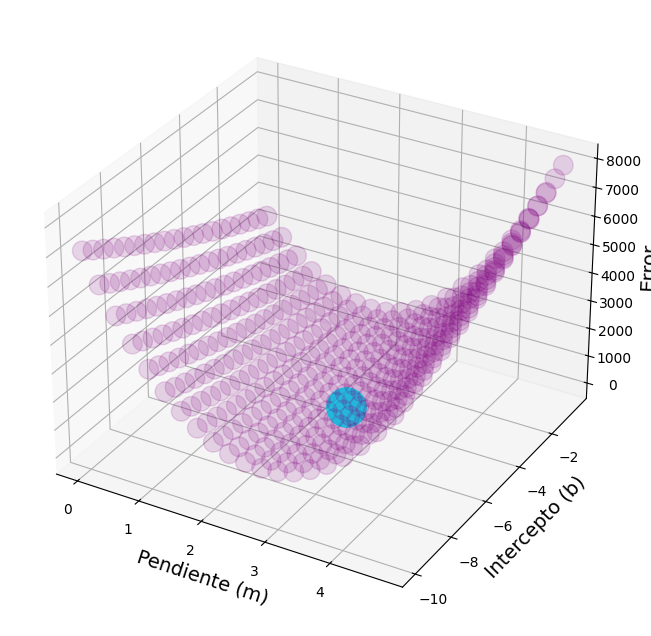

In [34]:
def error_RSS(m, b): # m: pendiente, b: intercepto
    error = ((salario - (m * experiencia + b)) ** 2).sum()
    return error


# Generación de rejilla (pendientes, interceptos, errores)

puntos = np.zeros(shape=(400,3))
i = 0
for pendiente in np.arange(0, 5, 0.25):
    for intercepto in np.arange(-10, 0, 0.50):
        puntos[i][0] = pendiente
        puntos[i][1] = intercepto
        puntos[i][2] = error_RSS(pendiente, intercepto)
        i += 1

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

# Mínimo global
ax.scatter(2.45, -4.38, 4.03,
           marker="o", c="cyan", s=800)

# Todos los otros puntos
ax.scatter(puntos.T[0], puntos.T[1], puntos.T[2],
           marker="o", c="purple", s=200, alpha=0.15)

ax.set_xlabel('Pendiente (m)', size=14)
ax.set_ylabel('Intercepto (b)', size=14)
ax.set_zlabel('Error', size=14)
#ax.view_init(0, -30)
plt.show()

### Derivadas parciales de la función de error

In [65]:
m, b = sym.symbols("m b")

# Funcion de error
#error = (6.85 - (m*5 + b))**2 + (16.83 - (m*8 + b))**2 + (26.84 - (m*13 + b))**2
error = ((salario - (m * experiencia.flatten() + b))**2).sum()

# Derivadas
derivada_error_m = sym.diff(error, m)
derivada_error_b = sym.diff(error, b)

print("Derivada del error respecto a m:", derivada_error_m)
print("Derivada del error respecto a b:", derivada_error_b)

Derivada del error respecto a m: 52.0*b + 516.0*m - 1035.62
Derivada del error respecto a b: 6.0*b + 52.0*m - 101.04


La combinación de ambas derivadas nos da el **gradiente** que no es otra cosa que el vector de derivadas parciales.

Ahora el algoritmo del gradiente descendiente consistirá en encontrar los valores de las incógnitas que hacen que este gradiente sea el menor posible, es decir, el más cercano a 0 (la pendiente de la recta, plano o hiperplano más chica).

### Pseudocódigo del gradiente descendiente

1. iteraciones máximas = 10000 (por ejemplo)
2. iteración = 0
3. tasa de aprendizaje = 0.001 (esto es, cómo va a avanzar cada paso en cada iteración. Es el valor por el que se dividirá el gradiente y cuanto mayor sea, mayor será el paso, pero lo ideal es que se un intermedio)
4. inicialización aleatoria de parámetros (ej: b = 0 y m = 0)
5. mientras (iteración < iteraciones máximas) hacer:
    1. calcular gradientes en la posición actual (esto es, evaluar el vector gradiente con b y m)
    2. actualizar parámetros en función de los gradientes y la tasa de aprendizaje (esto es actualizar b y m de acuerdo al resultado anterior)
    3. iteración += 1

### Implementación del gradiente descendiente

In [66]:
iteraciones_max = 10000
tasa_aprendizaje = 0.001

# Inicializacion aleatoria pendiente e intercepto
pendiente = 0
intercepto = -10

errores = np.zeros(shape=(10000, 3))

for i in range(0, iteraciones_max):
    # Calculo de los gradientes
    gradientes = [ derivada_error_m.evalf(subs={ m: pendiente, b: intercepto }), 
                   derivada_error_b.evalf(subs={ m: pendiente, b: intercepto }) ]

    # Actualizacion de los parametros
    pendiente = pendiente - tasa_aprendizaje * gradientes[0]
    intercepto = intercepto - tasa_aprendizaje * gradientes[1]

    # Registro de los errores
    errores[i][0] = pendiente
    errores[i][1] = intercepto
    errores[i][2] = error_RSS(pendiente, intercepto)


# Valores calculados vía el Método de Mínimos Cuadrados de sklearn
# Pendiente (m): 2.44898163
# Intercepto (b): -4.382390816326527
    
print("Derivada pendiente (m) =", gradientes[0])
print("Derivada intercepto (b) =", gradientes[1])
print("m =", pendiente, "b =", intercepto)
    

Derivada pendiente (m) = 0.000218445852030267
Derivada intercepto (b) = -0.00216449575579388
m = 2.44835147659091 b = -4.37940660844884


### Visualización del descenso del error

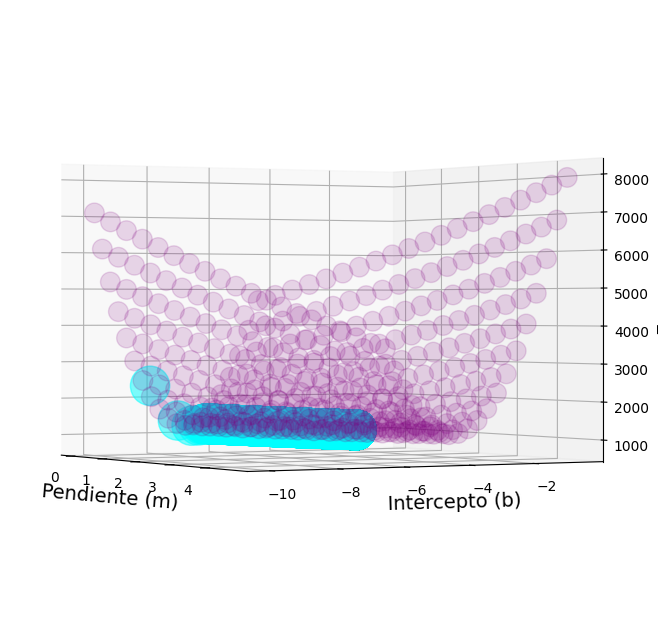

In [68]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

# Camino decreciente de errores
ax.scatter(errores.T[0], errores.T[1], errores.T[2],
           marker="o", c="cyan", s=800, alpha=0.5)

# Todos los otros puntos
ax.scatter(puntos.T[0], puntos.T[1], puntos.T[2],
           marker="o", c="purple", s=200, alpha=0.15)

ax.set_xlabel('Pendiente (m)', size=14)
ax.set_ylabel('Intercepto (b)', size=14)
ax.set_zlabel('Error', size=14)
ax.view_init(0, -30)
plt.show()